**Loading Datasets**  
cleaning and making training and test dataset

MNIST Dataset

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Download and load MNIST
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Convert to numpy array and reshape
# Get all images and flatten them
X_mnist = mnist_train.data.numpy().reshape(len(mnist_train.data), -1).T  # Shape: (784, 60000)

# Normalize to [0, 1] range
X_mnist = X_mnist / 255.0

# Convert to torch tensor with double precision to match AALS expectations (This is for linear model)
X_mnist = torch.from_numpy(X_mnist).double()


''' 
This is ready for Linear AA, slight modification might be needed for other models
'''
MNIST_train = X_mnist[:, :5000]

print(f"MNIST data shape: {MNIST_train.shape}")  # Should be (784, 60000)
print(f"Data type: {MNIST_train.dtype}")
print(f"Data range: [{MNIST_train.min():.2f}, {MNIST_train.max():.2f}]")

MNIST data shape: torch.Size([784, 5000])
Data type: torch.float64
Data range: [0.00, 1.00]


Sequence RNA dataset

In [2]:
#Download data also available at https://www.kaggle.com/datasets/alexandervc/scrnaseq-scatacseq-challenge-at-neurips-2021
import os
import urllib.request

# Define the local filename
destination = "./data/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad"

# This is the direct link to the processed challenge dataset on Figshare
# (Maintained by the Open Problems team)
url = "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE194122&format=file&file=GSE194122%5Fopenproblems%5Fneurips2021%5Fmultiome%5FBMMC%5Fprocessed%2Eh5ad%2Egz" 

print(f"Downloading dataset from original source (Figshare)...")

if not os.path.exists(destination):
    urllib.request.urlretrieve(url, destination)
    print("Download complete!")
else:
    print("File already exists.")

File already exists.


In [3]:
import scanpy as sc

# Load normally with Scanpy
import scanpy as sc


fn = './data/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad'
adata = sc.read(fn)
print(adata)

# 1. Subsample 1000 cells
# We use copy=True so we don't accidentally modify your original massive 'adata' object
adata_subset = sc.pp.subsample(adata, n_obs=1000, copy=True, random_state=42)

# 2. Extract the PCA matrix
# This is currently a numpy array of shape (1000, 50)
pca_data = adata_subset.obsm['GEX_X_pca']

# 3. Select the top N components
# Standard practice is often the top50, as lower components (e.g., 40-50) might be noise.
n_components = 50
pca_data_top = pca_data[:, :n_components]


# 1. Re-create the tensor as float64 (Double)
#    Note: .T is added here to transpose it as you mentioned
sequRNA_train = torch.tensor(pca_data_top, dtype=torch.float64).T

# 2. Move to the correct device (if you are using GPU, otherwise skip)
#    The error trace mentions 'device', so it's good practice to be explicit.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
sequRNA_train = sequRNA_train.to(device)

# 3. Verify shapes
#    AALS usually expects (Features x Samples) or (Samples x Features). 
#    Since you transposed, you now have (30 x 1000). 
print(f"Input shape: {sequRNA_train.shape}") 
print(f"Input type: {sequRNA_train.dtype}")  # Should say torch.float64


''' 
This is ready for Linear AA, slight modification might be needed for other models
'''

AnnData object with n_obs × n_vars = 69249 × 129921
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'
Using device: cpu
Input shape: torch.Size([50, 1000])
Input type: torch.float64


' \nThis is ready for Linear AA, slight modification might be needed for other models\n'

general Functions:  
NMI  
Confidence  
...

In [4]:
from scipy.spatial.distance import pdist, squareform
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'




def ArchetypeConsistency(XC1, XC2, mSST):
    """
    Calculates the consistency between two sets of archetypes (XC1 and XC2).
    """
    # 1. Calculate Squared Euclidean Distance between all archetypes
    D = squareform(pdist(np.hstack((XC1, XC2)).T, 'euclidean'))**2
    D = D[:XC1.shape[1], XC1.shape[1]:]

    # 2. Greedy Matching to pair archetypes
    i = []
    j = []
    v = []
    K = XC1.shape[1]
    
    for k in range(K):
        # Find minimum distance in the matrix
        min_index = np.unravel_index(np.argmin(D, axis=None), D.shape)
        i.append(min_index[0])
        j.append(min_index[1])
        v.append(D[i[-1], j[-1]]) # Record the error (distance)
        
        # 'Remove' these from future consideration
        D[i[-1], :] = np.inf
        D[:, j[-1]] = np.inf

    # 3. Calculate Consistency Score (R^2-like metric)
    consistency = 1 - np.mean(v) / mSST

    # 4. Calculate Inter-Set Similarity Index (ISI)
    # Correlation between matched archetypes
    D2 = np.abs(np.corrcoef(np.hstack((XC1, XC2)).T))
    D2 = D2[:K, K:]
    ISI = 1 / (2 * K * (K - 1)) * (np.sum(D2 / np.max(D2, axis=1, keepdims=True) + D2 / np.max(D2, axis=0, keepdims=True)) - 2 * K)
    
    return consistency, ISI

def preprocess(X):
    """
    Mean-centers the data and computes the total variance (mSST).
    """
    meanX = np.mean(X, axis=0)
    X_centered = X - meanX
    # Mean Sum of Squares Total (Total Variance)
    mSST = np.sum(np.mean(X_centered**2, axis=0))
    return X_centered, mSST

def calcMI(z1,z2):
    eps = 10e-16
    P = z1@z2.T
    PXY = P/P.sum()
    PXPY = np.outer(np.expand_dims(PXY.sum(1), axis=0),np.expand_dims(PXY.sum(0), axis=1))
    ind = np.nonzero(PXY>0)
    MI = np.sum(PXY*np.log(eps+PXY/(eps+PXPY)))
    return MI
    
def calcNMI(z1,z2):
    NMI=(2*calcMI(z1,z2))/(calcMI(z1,z1)+calcMI(z2,z2))
    #NMI = NMI.reshape((z1.shape[0], z1.shape[0]))
    
    return NMI

def plot_loss_arc(L,n_arc_list,i,color,model, dataset, savedir = None):


    fig, ax = plt.subplots(figsize=(15, 5),layout='constrained')

    ax.errorbar(n_arc_list,np.mean(L,axis=1),yerr=np.std(L,axis=1),c=color,label=f'{model} - {dataset}')

    ##
    # ax.set_xticks(n_arc_list,fontsize=25)
    ax.set_xticks(n_arc_list)       # Set the tick positions
    ax.tick_params(axis='x') # Set the font size separately
    ##

    ax.set_xlabel('Number of Archetypes',fontsize=30)
    ax.set_ylabel('Loss',fontsize=30)

    plt.legend(fontsize=30)

    plt.yticks(fontsize=25)
    plt.xticks(fontsize=25)    
    #plt.title(f'{model} - {dataset}',fontsize=30)

    if savedir is not None:
        plt.savefig(savedir+f"/loss_layer_"+str(i)+".png")
        plt.close()
    else:
        plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_nmi_stability(NMI,n_arc_list,model,dataset, colors, savedir = None):
    
    
    df = pd.DataFrame(NMI.T)
    df['Method'] = f'Model {model}'


    df = df.melt(id_vars='Method', var_name='Archetypes', value_name='NMI')
    fig, ax = plt.subplots(1,1,figsize = (15,5), layout='constrained')

    ax = sns.boxplot(x='Archetypes', y="NMI", hue="Method", showmeans=True, data=df,palette=colors,meanprops={"marker": "s", "markerfacecolor": "white", "markeredgecolor": "black"})
    ax.xaxis.grid(True, which='major')
    [ax.axvline(x+.5,color='k') for x in ax.get_xticks()]
    plt.xticks(np.arange(len(n_arc_list)),n_arc_list,fontsize=25)
    plt.yticks(fontsize=25)    
    ax.set_xlabel('Number of archetypes', fontsize=30)
    ax.set_ylabel('NMI', fontsize=30)

    ax.set_ylim([0,1.05])
    plt.legend(fontsize=30,loc = 'lower right')
    plt.title(f'{model} - {dataset}',fontsize=30)
    
    if savedir is not None:
        plt.savefig(savedir+f"/NMI_model_"+str(model)+"dataset_"+str(dataset)+".png")
        plt.close()
    else:
        plt.show()

Linear AA Implementation

In [5]:
from LinearAA.AALS import AALS
import torch
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools
colors = ["#EF476F",  "#06D6A0", "#FFD166", "#073B4C", "#118AB2", "#FF6B6B", "#C8A2C8"]

In [6]:
# Show small test
# running linear AA on mini subset, 4 times for each archetype, we run it multiple times for each archetype to see stability (NMI)
test_Linear_X = MNIST_train[:, :50]
n_runs = 4
n_arc_list = [f for f in range(2,15)]
Losses = np.zeros((len(n_arc_list),n_runs))
Ss = np.zeros((len(n_arc_list),n_runs),dtype=object)

for n in tqdm(n_arc_list):
    for i in range(n_runs):

        C,S,L,EV = AALS(test_Linear_X, n)
        Losses[n_arc_list.index(n),i] = L[-1]
        Ss[n_arc_list.index(n),i] = S
        

100%|██████████| 13/13 [00:21<00:00,  1.68s/it]


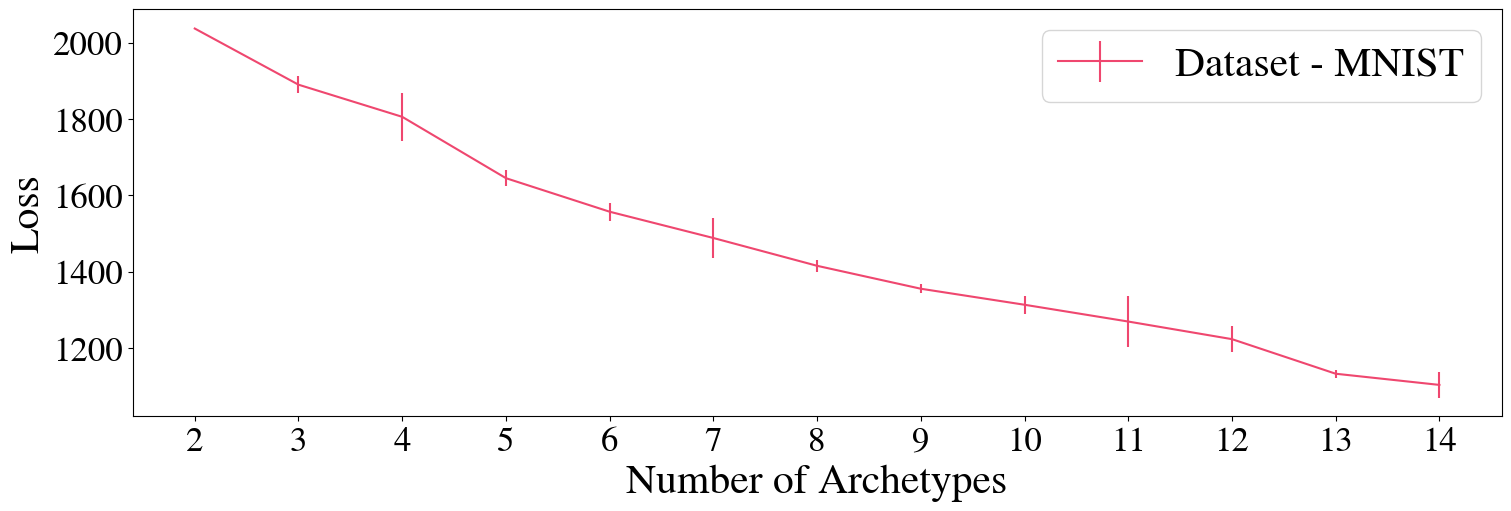

In [7]:
plot_loss_arc(Losses,n_arc_list,i,colors[0],'Dataset', 'MNIST', savedir = None)

100%|██████████| 13/13 [00:00<00:00, 552.62it/s]
C:\Users\fabia\AppData\Local\Temp\ipykernel_12252\2142883590.py:113: UserWarning: The palette list has more values (7) than needed (1), which may not be intended.
  ax = sns.boxplot(x='Archetypes', y="NMI", hue="Method", showmeans=True, data=df,palette=colors,meanprops={"marker": "s", "markerfacecolor": "white", "markeredgecolor": "black"})


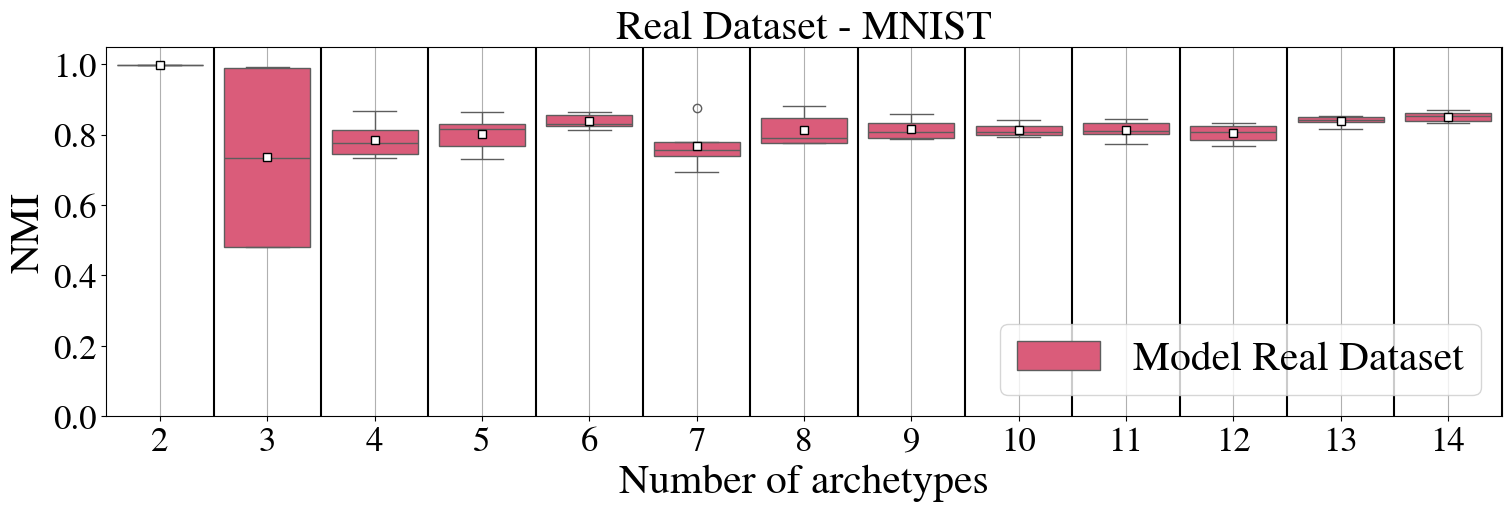

In [8]:
test = itertools.combinations(range(n_runs), 2)
t = list(test)
calcIDX = np.array(t)

NMI = np.zeros((len(n_arc_list),len(calcIDX)))

for n in tqdm(n_arc_list):
    for j in range(len(calcIDX)):

        S1 = np.asarray(Ss[n_arc_list.index(n),calcIDX[j,0]])
        S2 = np.asarray(Ss[n_arc_list.index(n),calcIDX[j,1]])


        NMI[n_arc_list.index(n),j] = calcNMI(S1,S2)

plot_nmi_stability(NMI,n_arc_list, 'Real Dataset','MNIST',colors)

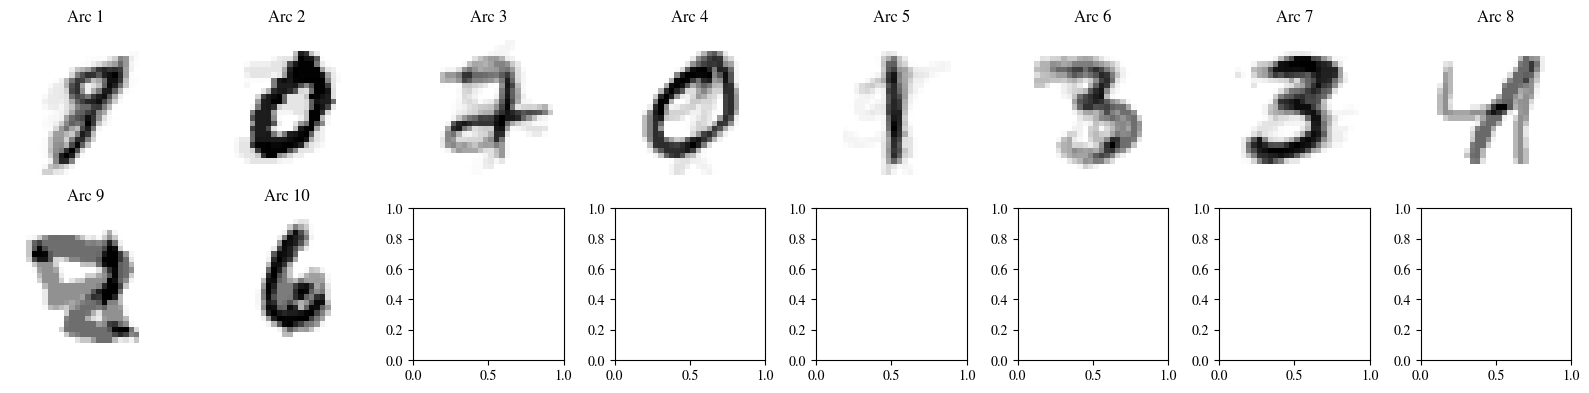

In [9]:
n_archetypes = 10
C_final, S_final, L_final, EV_final = AALS(test_Linear_X, n_archetypes)

# 1. Calculate the actual Archetypes (Z = X * C)
# Ensure both are the same type (likely Torch tensors based on your output)
if isinstance(C_final, np.ndarray):
    C_final = torch.from_numpy(C_final)
if isinstance(test_Linear_X, np.ndarray):
    test_Linear_X = torch.from_numpy(test_Linear_X)

# Matrix Multiplication: (784x100) @ (100x16) -> (784x16)
archetypes_matrix = torch.matmul(test_Linear_X, C_final) 
# 2. Visualize
n_archetypes = archetypes_matrix.shape[1] # Should be 16
rows = int(n_archetypes // 8) + 1  # Adjust grid (2x8 = 16)
cols = 8 # Adjust grid (2x8 = 16)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 2))
axes = axes.flatten()

for i in range(n_archetypes):
    # Get the i-th archetype (all 784 pixels)
    arc_vector = archetypes_matrix[:, i]
    
    # Reshape to 28x28 image
    arc_img = arc_vector.reshape(28, 28).detach().numpy() # detach if it requires grad
    
    axes[i].imshow(arc_img, cmap='gray_r')
    axes[i].set_title(f"Arc {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

AAnet

Midaa